# Simulation-Based Inference for an Adaptive-Network Epidemic Model

This notebook is organized around the assignment workflow:

1. Load the observed data
2. Build summary statistics
3. Run rejection ABC
4. Compare different summary sets
5. Visualize the posterior
6. Extend to a stronger SBI method

## 1. Setup

Fill in the local paths below after you clone or download the simulator and data.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from simulator import simulate

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

RNG = np.random.default_rng(42)
PROJECT_ROOT, DATA_DIR, RESULTS_DIR

(PosixPath('/Users/jiayibaobei/Desktop/Simulation-Based-Inference-for-an-Adaptive-Network-Epidemic-Model'),
 PosixPath('/Users/jiayibaobei/Desktop/Simulation-Based-Inference-for-an-Adaptive-Network-Epidemic-Model/data'),
 PosixPath('/Users/jiayibaobei/Desktop/Simulation-Based-Inference-for-an-Adaptive-Network-Epidemic-Model/results'))

## 2. Load observed data

Expected files from the assignment repo:

- `infected_timeseries.csv`
- `rewiring_timeseries.csv`
- `final_degree_histograms.csv`

Adjust filenames if the upstream repo uses slightly different names.

In [3]:
def try_read_csv(path: Path):
    if path.exists():
        return pd.read_csv(path)
    print(f"Missing file: {path}")
    return None


infected_obs = try_read_csv(DATA_DIR / "infected_timeseries.csv")
rewiring_obs = try_read_csv(DATA_DIR / "rewiring_timeseries.csv")
degree_obs = try_read_csv(DATA_DIR / "final_degree_histograms.csv")

infected_obs, rewiring_obs, degree_obs

(      replicate_id  time  infected_fraction
 0                0     0              0.025
 1                0     1              0.050
 2                0     2              0.090
 3                0     3              0.150
 4                0     4              0.195
 ...            ...   ...                ...
 8035            39   196              0.000
 8036            39   197              0.000
 8037            39   198              0.000
 8038            39   199              0.000
 8039            39   200              0.000
 
 [8040 rows x 3 columns],
       replicate_id  time  rewire_count
 0                0     0             0
 1                0     1            32
 2                0     2            28
 3                0     3            50
 4                0     4            53
 ...            ...   ...           ...
 8035            39   196             0
 8036            39   197             0
 8037            39   198             0
 8038            39   199       

If the files load correctly, inspect their shapes and column names before writing the simulator wrapper.

In [4]:
for name, df in {
    "infected_obs": infected_obs,
    "rewiring_obs": rewiring_obs,
    "degree_obs": degree_obs,
}.items():
    if df is not None:
        print(name)
        print(df.shape)
        display(df.head())


infected_obs
(8040, 3)


,replicate_id,time,infected_fraction
0,0,0,0.025
1,0,1,0.050
2,0,2,0.090
3,0,3,0.150
4,0,4,0.195


rewiring_obs
(8040, 3)


,replicate_id,time,rewire_count
0,0,0,0
1,0,1,32
2,0,2,28
3,0,3,50
4,0,4,53


degree_obs
(1240, 3)


,replicate_id,degree,count
0,0,0,0
1,0,1,0
2,0,2,0
3,0,3,0
4,0,4,4


In [5]:
degree_obs.groupby("replicate_id")["count"].sum().head()


replicate_id
0    200
1    200
2    200
3    200
4    200
Name: count, dtype: int64

## 3. Simulator wrapper

Replace the body of `simulate_one` with the exact call from the provided simulator code.

In [16]:
def simulate_one(beta: float, gamma: float, rho: float, seed: int):
    infected, rewiring, degrees = simulate(
        beta=beta,
        gamma=gamma,
        rho=rho,
        rng=np.random.default_rng(seed),
    )
    return {
        "infected": infected,
        "rewiring": rewiring,
        "degrees": degrees,
    }


def simulate_replicates(beta: float, gamma: float, rho: float, n_reps: int = 40, seed: int = 42):
    local_rng = np.random.default_rng(seed)
    return [simulate_one(beta, gamma, rho, int(local_rng.integers(0, 2**31 - 1))) for _ in range(n_reps)]

## 4. Summary statistics

These summaries are a strong baseline because they capture epidemic shape, rewiring behavior, and the final network structure.

In [17]:
def summarize_time_series(x):
    x = np.asarray(x, dtype=float)
    t_peak = int(np.argmax(x))
    positive_idx = np.flatnonzero(x > 0)
    extinction_time = float(positive_idx[-1]) if len(positive_idx) else 0.0
    return {
        "peak": float(np.max(x)),
        "time_of_peak": float(t_peak),
        "final": float(x[-1]),
        "auc": float(np.trapezoid(x)),
        "mean": float(np.mean(x)),
        "var": float(np.var(x)),
        "zero_fraction": float(np.mean(x == 0)),
        "extinction_time": extinction_time,
    }


def summarize_degree_histogram(degree_hist):
    counts = np.asarray(degree_hist, dtype=float)
    degree_values = np.arange(len(counts), dtype=float)
    total_nodes = counts.sum()

    if total_nodes == 0:
        raise ValueError("Degree histogram is empty.")

    mean_degree = float(np.sum(degree_values * counts) / total_nodes)
    var_degree = float(np.sum(((degree_values - mean_degree) ** 2) * counts) / total_nodes)
    frac_deg_le_5 = float(np.sum(counts[:6]) / total_nodes)
    frac_deg_ge_15 = float(np.sum(counts[15:]) / total_nodes)

    return {
        "mean_degree": mean_degree,
        "var_degree": var_degree,
        "frac_deg_le_5": frac_deg_le_5,
        "frac_deg_ge_15": frac_deg_ge_15,
    }


def summarize_replicate(rep):
    infected_stats = {f"infected_{k}": v for k, v in summarize_time_series(rep["infected"]).items()}
    rewiring_stats = {f"rewiring_{k}": v for k, v in summarize_time_series(rep["rewiring"]).items()}
    degree_stats = summarize_degree_histogram(rep["degrees"])
    return infected_stats | rewiring_stats | degree_stats


def summarize_replicates(replicates):
    per_rep = pd.DataFrame([summarize_replicate(rep) for rep in replicates])
    return per_rep.mean(axis=0)


If the observed data are not already packaged as replicate dictionaries, convert them into the same format used by `summarize_replicate`.

In [18]:
def build_observed_replicates(infected_df, rewiring_df, degree_df):
    replicates = []
    replicate_ids = sorted(set(infected_df["replicate_id"]))

    for rep_id in replicate_ids:
        infected = (
            infected_df.loc[infected_df["replicate_id"] == rep_id]
            .sort_values("time")["infected_fraction"]
            .to_numpy()
        )
        rewiring = (
            rewiring_df.loc[rewiring_df["replicate_id"] == rep_id]
            .sort_values("time")["rewire_count"]
            .to_numpy()
        )
        degrees = (
            degree_df.loc[degree_df["replicate_id"] == rep_id]
            .sort_values("degree")["count"]
            .to_numpy()
        )

        replicates.append({
            "infected": infected,
            "rewiring": rewiring,
            "degrees": degrees,
        })

    return replicates


observed_replicates = build_observed_replicates(infected_obs, rewiring_obs, degree_obs)
observed_summary = summarize_replicates(observed_replicates)
observed_summary

infected_peak                 0.657125
infected_time_of_peak         8.750000
infected_final                0.000000
infected_auc                 11.386500
infected_mean                 0.056711
infected_var                  0.018428
infected_zero_fraction        0.622886
infected_extinction_time     74.800000
rewiring_peak                98.125000
rewiring_time_of_peak         5.500000
rewiring_final                0.000000
rewiring_auc                545.150000
rewiring_mean                 2.712189
rewiring_var                181.165241
rewiring_zero_fraction        0.936940
rewiring_extinction_time     13.400000
mean_degree                  10.017250
var_degree                   10.341022
frac_deg_le_5                 0.069375
frac_deg_ge_15                0.090625
dtype: float64

## 5. Prior and distance

The assignment's exact prior bounds should be copied here from the provided specification.

In [19]:
PRIOR_BOUNDS = {
    "beta": (0.05, 0.50),
    "gamma": (0.02, 0.20),
    "rho": (0.0, 0.8),
}


def sample_prior(n_samples: int, rng: np.random.Generator):
    return pd.DataFrame({
        name: rng.uniform(low, high, size=n_samples)
        for name, (low, high) in PRIOR_BOUNDS.items()
    })


def fit_summary_scale(summary_df: pd.DataFrame):
    scale = summary_df.std(axis=0).replace(0.0, 1.0)
    return scale


def weighted_distance(sim_summary, obs_summary, scale, selected_columns=None):
    if selected_columns is None:
        selected_columns = obs_summary.index
    diff = (sim_summary[selected_columns] - obs_summary[selected_columns]) / scale[selected_columns]
    return float(np.sqrt(np.sum(np.square(diff))))

## 6. Pilot simulations for normalization

Use a small pilot run to estimate the scale of each summary statistic before the main ABC run.

In [20]:
def run_pilot(n_pilot: int = 100, n_reps: int = 40, seed: int = 123):
    pilot_rng = np.random.default_rng(seed)
    theta = sample_prior(n_pilot, pilot_rng)
    summaries = []

    for row in theta.itertuples(index=False):
        reps = simulate_replicates(row.beta, row.gamma, row.rho, n_reps=n_reps, seed=int(pilot_rng.integers(0, 2**31 - 1)))
        summaries.append(summarize_replicates(reps))

    summary_df = pd.DataFrame(summaries)
    return theta, summary_df, fit_summary_scale(summary_df)


pilot_theta, pilot_summaries, summary_scale = run_pilot(n_pilot=20)
summary_scale

infected_peak                 0.231580
infected_time_of_peak         3.472604
infected_final                0.002767
infected_auc                  9.009213
infected_mean                 0.044828
infected_var                  0.014009
infected_zero_fraction        0.203638
infected_extinction_time     40.931305
rewiring_peak                53.889300
rewiring_time_of_peak         2.349942
rewiring_final                1.000000
rewiring_auc                253.091476
rewiring_mean                 1.259162
rewiring_var                147.068960
rewiring_zero_fraction        0.034781
rewiring_extinction_time      7.386475
mean_degree                   0.048231
var_degree                    3.203297
frac_deg_le_5                 0.034237
frac_deg_ge_15                0.025025
dtype: float64

## 7. Rejection ABC

This keeps the closest simulations to the observed summary vector.

In [21]:
def rejection_abc(observed_summary, summary_scale, selected_columns, n_samples=1000, n_reps=40, accept_frac=0.01, seed=2024):
    abc_rng = np.random.default_rng(seed)
    theta = sample_prior(n_samples, abc_rng)
    rows = []

    for row in theta.itertuples(index=False):
        reps = simulate_replicates(row.beta, row.gamma, row.rho, n_reps=n_reps, seed=int(abc_rng.integers(0, 2**31 - 1)))
        sim_summary = summarize_replicates(reps)
        dist = weighted_distance(sim_summary, observed_summary, summary_scale, selected_columns)
        rows.append({
            "beta": row.beta,
            "gamma": row.gamma,
            "rho": row.rho,
            "distance": dist,
        })

    results = pd.DataFrame(rows).sort_values("distance", ascending=True).reset_index(drop=True)
    n_accept = max(1, int(np.ceil(accept_frac * len(results))))
    accepted = results.head(n_accept).copy()
    return results, accepted


SUMMARY_SETS = {
    "infected_only": [
        "infected_peak",
        "infected_time_of_peak",
        "infected_auc",
        "infected_extinction_time",
    ],
    "infected_plus_rewiring": [
        "infected_peak",
        "infected_time_of_peak",
        "infected_auc",
        "infected_extinction_time",
        "rewiring_peak",
        "rewiring_time_of_peak",
        "rewiring_auc",
        "rewiring_zero_fraction",
    ],
    "full": [
        "infected_peak",
        "infected_time_of_peak",
        "infected_auc",
        "infected_extinction_time",
        "rewiring_peak",
        "rewiring_time_of_peak",
        "rewiring_auc",
        "rewiring_zero_fraction",
        "mean_degree",
        "var_degree",
        "frac_deg_le_5",
        "frac_deg_ge_15",
    ],
    "infected_only_legacy": [
        "infected_peak",
        "infected_time_of_peak",
        "infected_final",
        "infected_auc",
    ],
    "infected_plus_rewiring_legacy": [
        "infected_peak",
        "infected_time_of_peak",
        "infected_final",
        "infected_auc",
        "rewiring_peak",
        "rewiring_time_of_peak",
        "rewiring_final",
        "rewiring_auc",
    ],
    "full_legacy": [
        "infected_peak",
        "infected_time_of_peak",
        "infected_final",
        "infected_auc",
        "rewiring_peak",
        "rewiring_time_of_peak",
        "rewiring_final",
        "rewiring_auc",
        "mean_degree",
        "var_degree",
        "frac_deg_le_5",
        "frac_deg_ge_15",
    ],
}

## 8. Posterior plots

In [22]:
def plot_marginals(accepted_df, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, col in zip(axes, ["beta", "gamma", "rho"]):
        sns.histplot(accepted_df[col], bins=20, kde=True, ax=ax)
        ax.set_title(col)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_pairwise(accepted_df, title):
    g = sns.pairplot(accepted_df[["beta", "gamma", "rho"]], corner=True)
    g.fig.suptitle(title, y=1.02)
    return g

## 9. Summary-set comparison

Run the same ABC pipeline with different summary sets to demonstrate which information is needed to distinguish `beta` from `rho`.

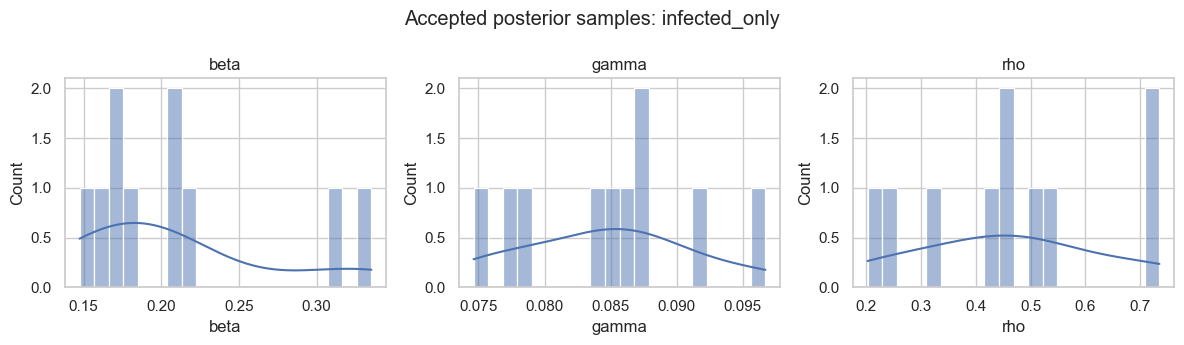

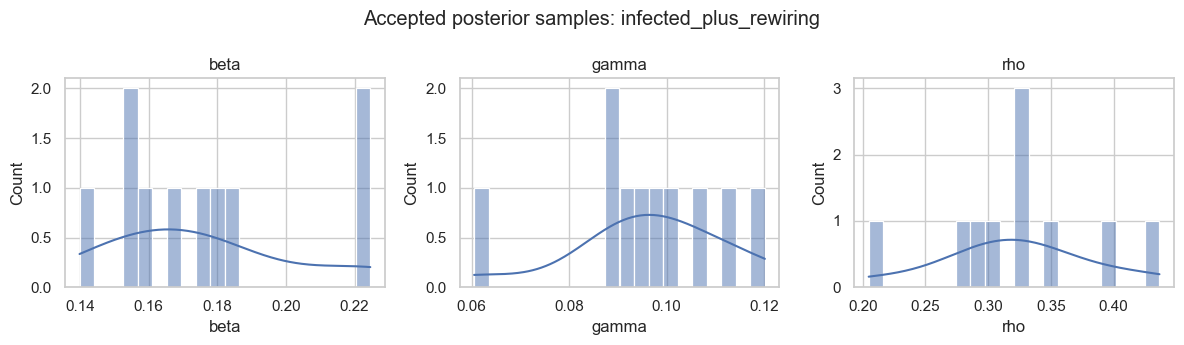

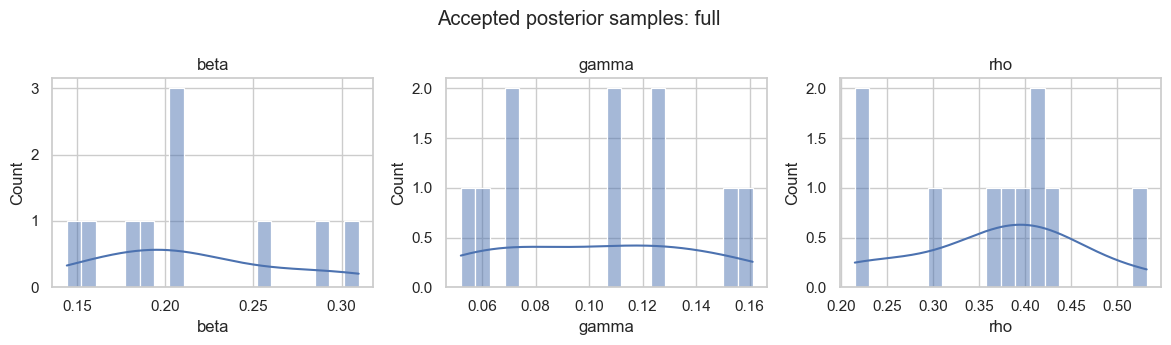

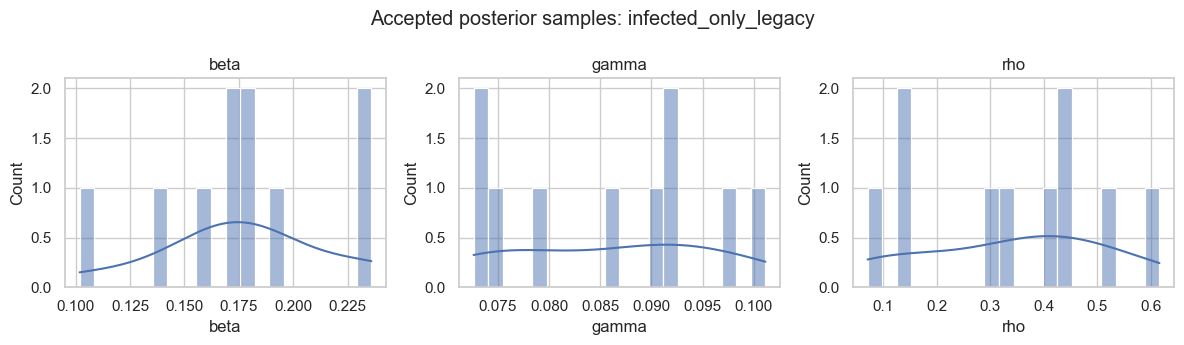

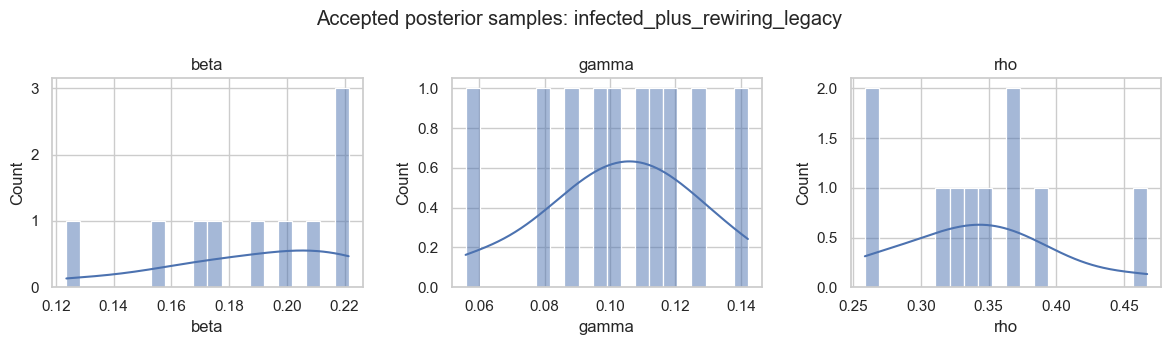

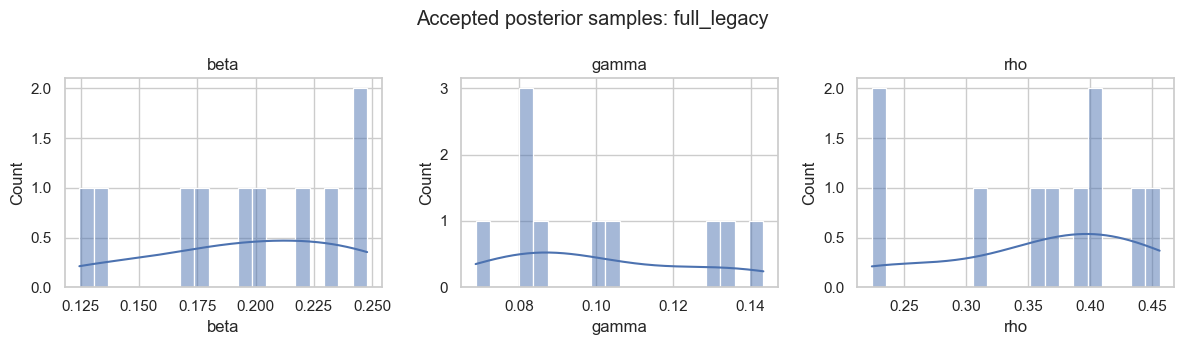

,summary_set,n_accepted,beta_mean,gamma_mean,rho_mean,distance_min,distance_max
0,infected_only,10,0.210882,0.084678,0.462094,0.147627,0.473450
1,infected_plus_rewiring,10,0.176169,0.096004,0.323113,0.349393,1.196859
2,full,10,0.214789,0.103835,0.368498,1.607033,2.023420
3,infected_only_legacy,10,0.177219,0.085976,0.340073,0.115273,0.435605
4,infected_plus_rewiring_legacy,10,0.188467,0.102893,0.342655,0.376923,1.073614
5,full_legacy,10,0.195273,0.101628,0.359378,0.733487,1.615941


In [23]:
all_results = {}
comparison_rows = []

for i, (name, columns) in enumerate(SUMMARY_SETS.items()):
    results, accepted = rejection_abc(
        observed_summary=observed_summary,
        summary_scale=summary_scale,
        selected_columns=columns,
        n_samples=500,
        n_reps=40,
        accept_frac=0.02,
        seed=2024 + i,
    )
    all_results[name] = {"results": results, "accepted": accepted}
    comparison_rows.append({
        "summary_set": name,
        "n_accepted": len(accepted),
        "beta_mean": accepted["beta"].mean(),
        "gamma_mean": accepted["gamma"].mean(),
        "rho_mean": accepted["rho"].mean(),
        "distance_min": accepted["distance"].min(),
        "distance_max": accepted["distance"].max(),
    })

    plot_marginals(accepted, f"Accepted posterior samples: {name}")
    plt.show()

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

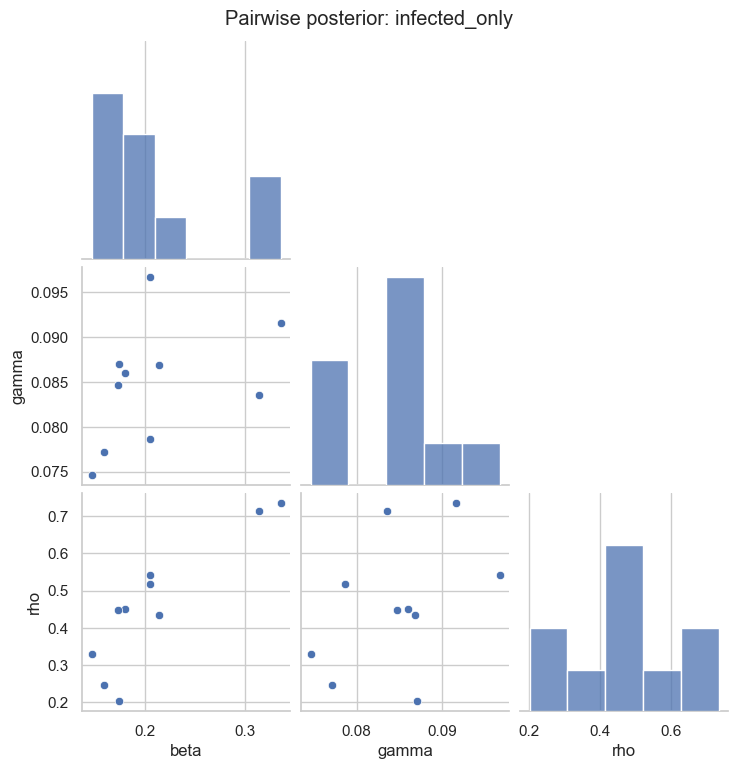

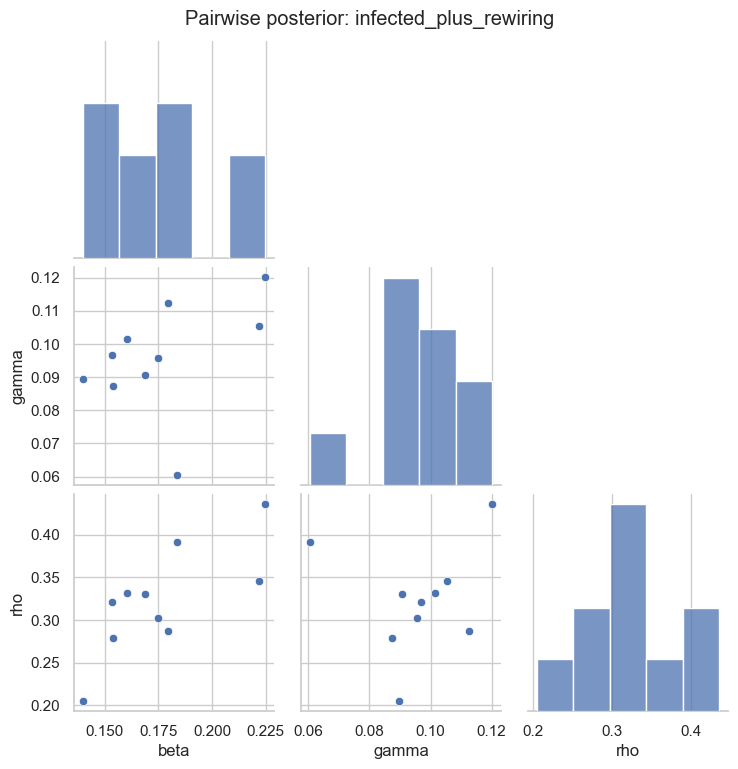

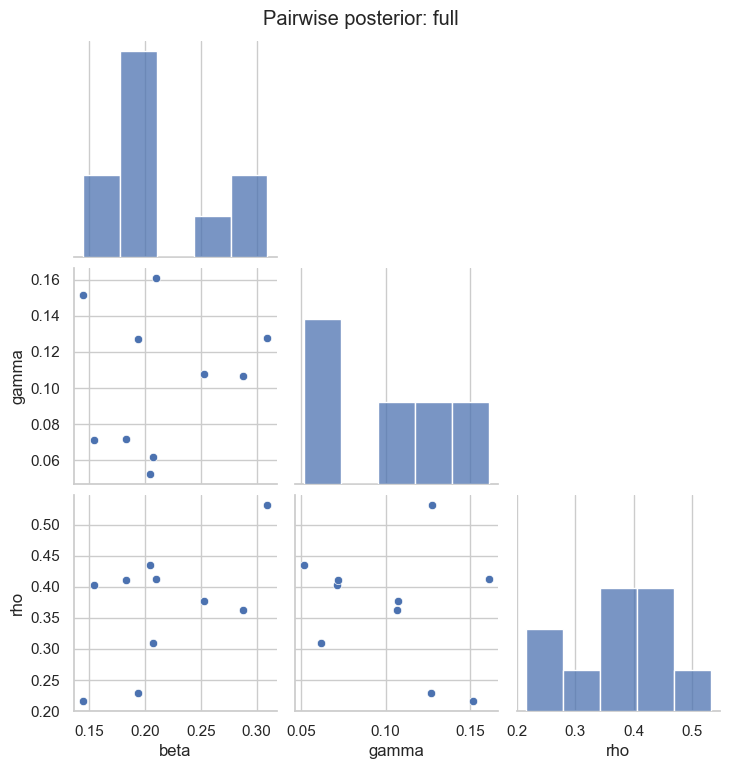

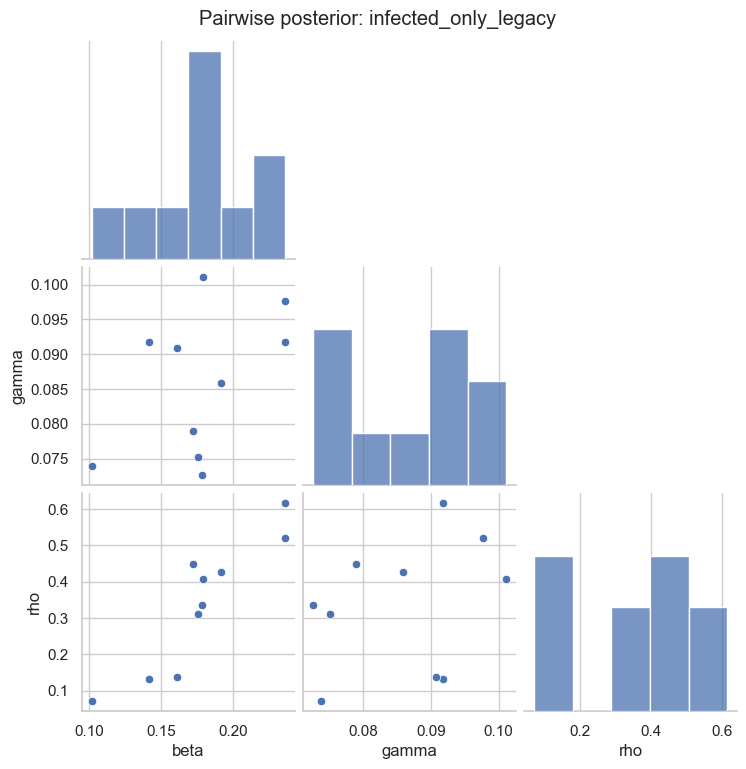

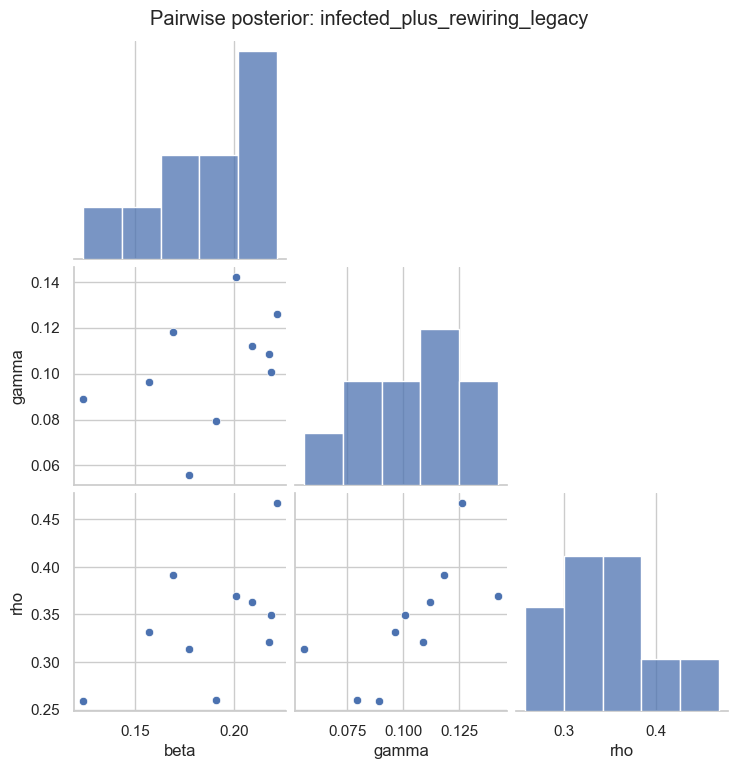

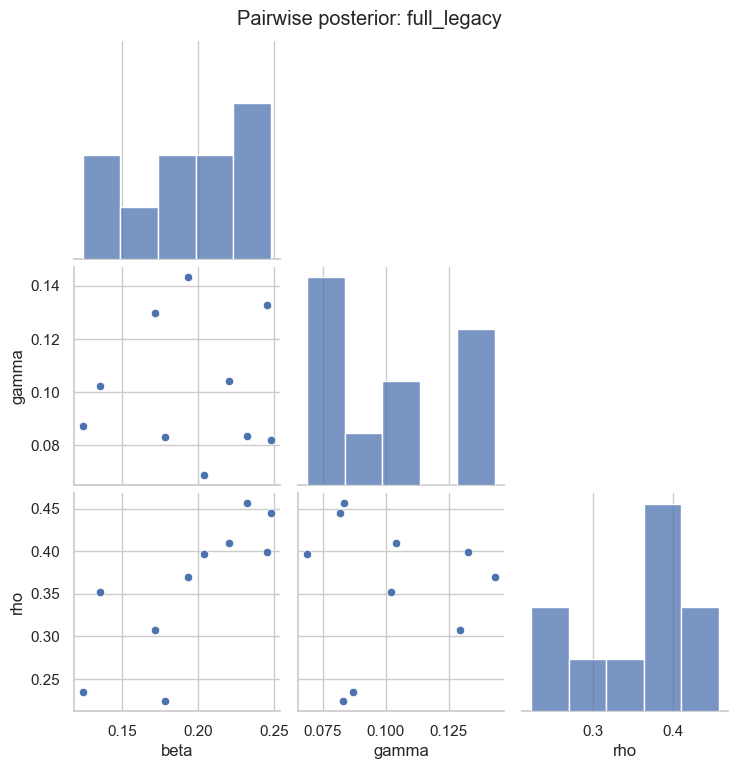

In [24]:
for name, payload in all_results.items():
    plot_pairwise(payload["accepted"], f"Pairwise posterior: {name}")
    plt.show()

In [25]:
final_results, final_accepted = rejection_abc(
    observed_summary=observed_summary,
    summary_scale=summary_scale,
    selected_columns=SUMMARY_SETS["infected_plus_rewiring"],
    n_samples=100000,
    n_reps=40,
    accept_frac=0.01,
    seed=2024,
)

print("Accepted samples:", len(final_accepted))
final_accepted.head()


Accepted samples: 1000


,beta,gamma,rho,distance
0,0.160346,0.080436,0.303759,0.175272
1,0.157687,0.080658,0.326353,0.198730
2,0.157037,0.082239,0.316112,0.200479
3,0.157269,0.082803,0.325293,0.221084
4,0.146406,0.083055,0.282479,0.230208


In [29]:
final_accepted.columns.tolist()


['beta', 'gamma', 'rho', 'distance']

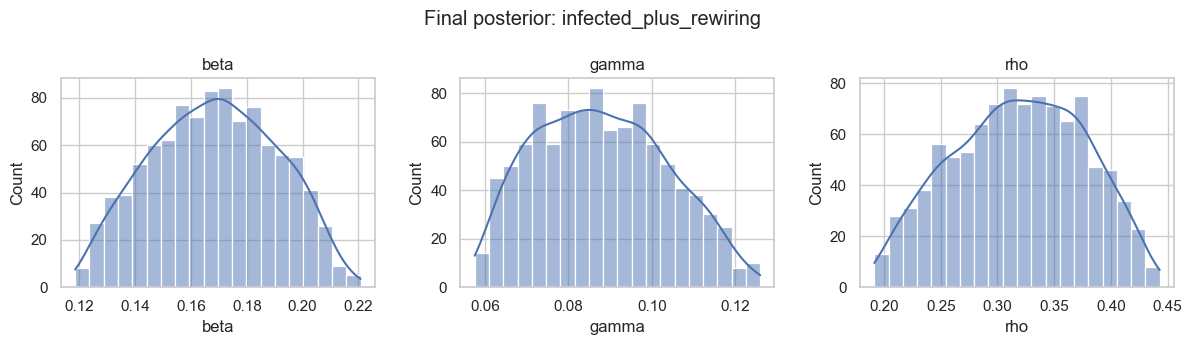

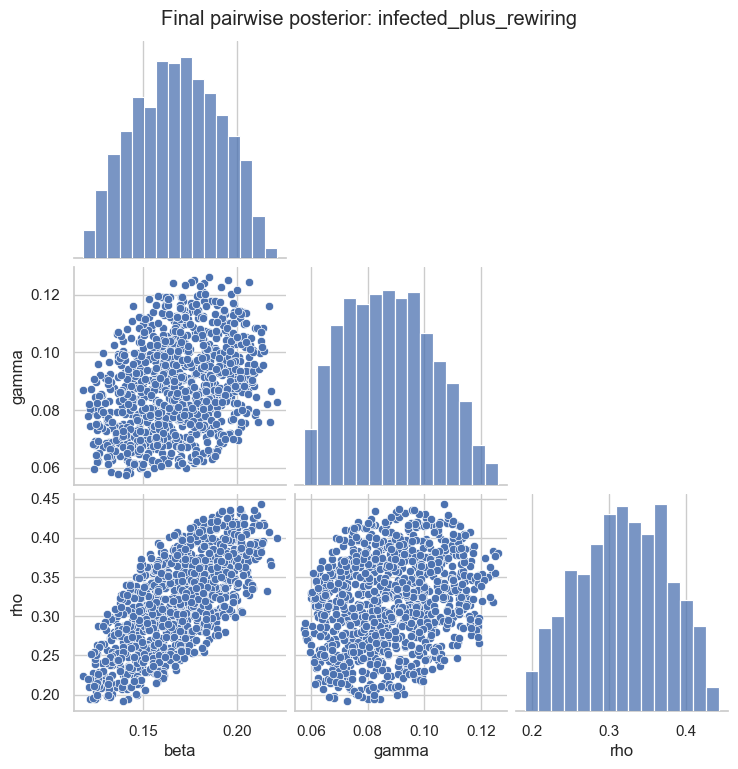

In [26]:
plot_marginals(final_accepted, "Final posterior: infected_plus_rewiring")
plt.show()

plot_pairwise(final_accepted, "Final pairwise posterior: infected_plus_rewiring")
plt.show()


In [30]:
final_accepted[["beta", "gamma", "rho"]].corr()

,beta,gamma,rho
beta,1.000000,0.316794,0.692400
gamma,0.316794,1.000000,0.250632
rho,0.692400,0.250632,1.000000


In [27]:
final_accepted[["beta", "gamma", "rho"]].describe()


,beta,gamma,rho
count,1000.000000,1000.000000,1000.000000
mean,0.168268,0.087876,0.318524
std,0.022311,0.015643,0.057741
min,0.118443,0.057547,0.191419
25%,0.151044,0.075079,0.275270
50%,0.168599,0.087042,0.320532
75%,0.185141,0.099077,0.364041
max,0.220819,0.125994,0.443022


In [28]:
final_accepted[["beta", "gamma", "rho"]].mean()


beta     0.168268
gamma    0.087876
rho      0.318524
dtype: float64

## 10. Advanced method

The simplest upgrade is regression-adjusted ABC. Add it after the baseline is working so you can compare the accepted samples before and after adjustment.

In [ ]:
def regression_adjustment_placeholder():
    raise NotImplementedError("Implement regression-adjusted ABC or replace this section with SMC-ABC.")

## 11. Notes for the report

Keep track of:

- exact prior bounds
- chosen summaries
- normalization method
- number of simulations
- acceptance threshold
- comparison across summary sets
- whether rewiring and degree summaries improve identifiability of `rho`

In [ ]:
from sklearn.linear_model import LinearRegression

def regression_adjust_abc(accepted_params, accepted_summaries, observed_summary, selected_columns):
    X = accepted_summaries[selected_columns].copy()
    s_obs = observed_summary[selected_columns].copy()

    adjusted = accepted_params.copy()

    for param in ["beta", "gamma", "rho"]:
        y = accepted_params[param].to_numpy()
        model = LinearRegression()
        model.fit(X, y)

        fitted = model.predict(X)
        intercept = model.predict(pd.DataFrame([s_obs], columns=selected_columns))[0]

        adjusted[param] = intercept + (y - fitted)

    return adjusted


In [ ]:
adjusted_params = regression_adjust_abc(
    accepted_params=accepted_params,
    accepted_summaries=accepted_summaries,
    observed_summary=observed_summary,
    selected_columns=SUMMARY_SETS["infected_plus_rewiring"],
)


In [ ]:
plot_marginals(accepted_params, "Rejection ABC posterior")
plt.show()

plot_marginals(adjusted_params, "Regression-adjusted ABC posterior")
plt.show()

print("Before adjustment")
display(accepted_params[["beta", "gamma", "rho"]].describe())

print("After adjustment")
display(adjusted_params[["beta", "gamma", "rho"]].describe())


## 12. ABC-MCMC

This section runs a fixed-tolerance ABC-MCMC chain using the same summary set and distance as the rejection ABC baseline. It starts from the best accepted rejection-ABC draw and uses the rejection-ABC acceptance cutoff as the ABC tolerance.


In [31]:
def simulate_summary_distance(beta, gamma, rho, observed_summary, summary_scale, selected_columns, n_reps=40, seed=2024):
    reps = simulate_replicates(beta, gamma, rho, n_reps=n_reps, seed=seed)
    sim_summary = summarize_replicates(reps)
    dist = weighted_distance(sim_summary, observed_summary, summary_scale, selected_columns)
    return sim_summary, dist


def in_prior_bounds(theta):
    return all(
        PRIOR_BOUNDS[name][0] <= value <= PRIOR_BOUNDS[name][1]
        for name, value in zip(["beta", "gamma", "rho"], theta)
    )


def abc_mcmc(
    observed_summary,
    summary_scale,
    selected_columns,
    start_theta,
    epsilon,
    proposal_scale,
    n_steps=5000,
    n_reps=40,
    burn_in=1000,
    thin=5,
    seed=2025,
):
    rng = np.random.default_rng(seed)
    current = np.asarray(start_theta, dtype=float).copy()
    _, current_dist = simulate_summary_distance(
        current[0], current[1], current[2],
        observed_summary=observed_summary,
        summary_scale=summary_scale,
        selected_columns=selected_columns,
        n_reps=n_reps,
        seed=int(rng.integers(0, 2**31 - 1)),
    )

    rows = []
    accepted_moves = 0

    for step in range(n_steps):
        proposal = current + rng.normal(scale=proposal_scale, size=3)
        accepted = False
        proposal_dist = np.nan

        if in_prior_bounds(proposal):
            _, proposal_dist = simulate_summary_distance(
                proposal[0], proposal[1], proposal[2],
                observed_summary=observed_summary,
                summary_scale=summary_scale,
                selected_columns=selected_columns,
                n_reps=n_reps,
                seed=int(rng.integers(0, 2**31 - 1)),
            )
            if proposal_dist <= epsilon:
                current = proposal
                current_dist = proposal_dist
                accepted = True
                accepted_moves += 1

        rows.append({
            "step": step,
            "beta": current[0],
            "gamma": current[1],
            "rho": current[2],
            "distance": current_dist,
            "accepted_move": int(accepted),
        })

        if (step + 1) % 500 == 0:
            print(f"Completed {step + 1} / {n_steps} MCMC steps", flush=True)

    chain = pd.DataFrame(rows)
    posterior = chain.iloc[burn_in::thin].reset_index(drop=True)
    acceptance_rate = chain["accepted_move"].mean()
    return chain, posterior, acceptance_rate


In [32]:
mcmc_columns = SUMMARY_SETS["infected_plus_rewiring"]
mcmc_start = final_accepted.sort_values("distance").iloc[0][["beta", "gamma", "rho"]].to_numpy()
mcmc_epsilon = final_accepted["distance"].max()
mcmc_proposal_scale = (0.35 * final_accepted[["beta", "gamma", "rho"]].std()).clip(lower=0.002).to_numpy()

mcmc_chain, mcmc_posterior, mcmc_acceptance_rate = abc_mcmc(
    observed_summary=observed_summary,
    summary_scale=summary_scale,
    selected_columns=mcmc_columns,
    start_theta=mcmc_start,
    epsilon=mcmc_epsilon,
    proposal_scale=mcmc_proposal_scale,
    n_steps=5000,
    n_reps=40,
    burn_in=1000,
    thin=5,
    seed=2025,
)

print("ABC-MCMC acceptance rate:", round(mcmc_acceptance_rate, 3))
print("Retained posterior samples:", len(mcmc_posterior))
mcmc_posterior[["beta", "gamma", "rho"]].describe()


Completed 500 / 5000 MCMC steps
Completed 1000 / 5000 MCMC steps
Completed 1500 / 5000 MCMC steps
Completed 2000 / 5000 MCMC steps
Completed 2500 / 5000 MCMC steps
Completed 3000 / 5000 MCMC steps
Completed 3500 / 5000 MCMC steps
Completed 4000 / 5000 MCMC steps
Completed 4500 / 5000 MCMC steps
Completed 5000 / 5000 MCMC steps
ABC-MCMC acceptance rate: 0.736
Retained posterior samples: 800


,beta,gamma,rho
count,800.000000,800.000000,800.000000
mean,0.175594,0.093601,0.335537
std,0.020767,0.017107,0.048410
min,0.122035,0.057752,0.198778
25%,0.158507,0.079535,0.303924
50%,0.175991,0.093506,0.336107
75%,0.191524,0.108081,0.372733
max,0.222676,0.126303,0.439145


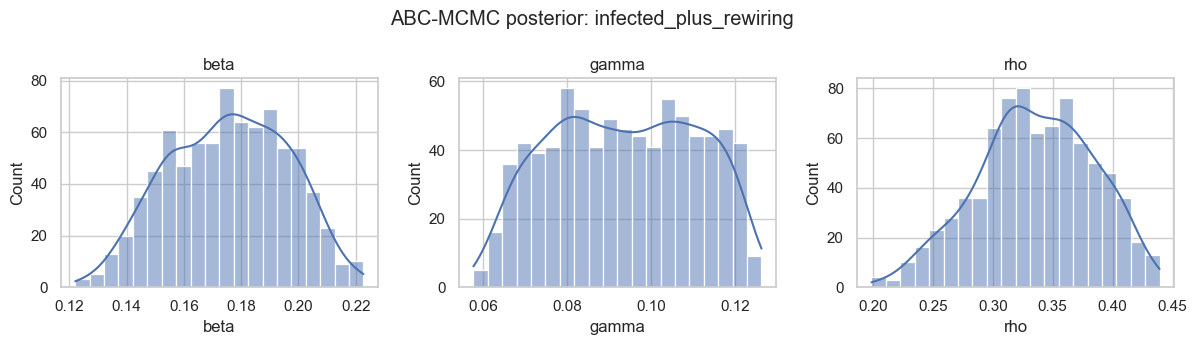

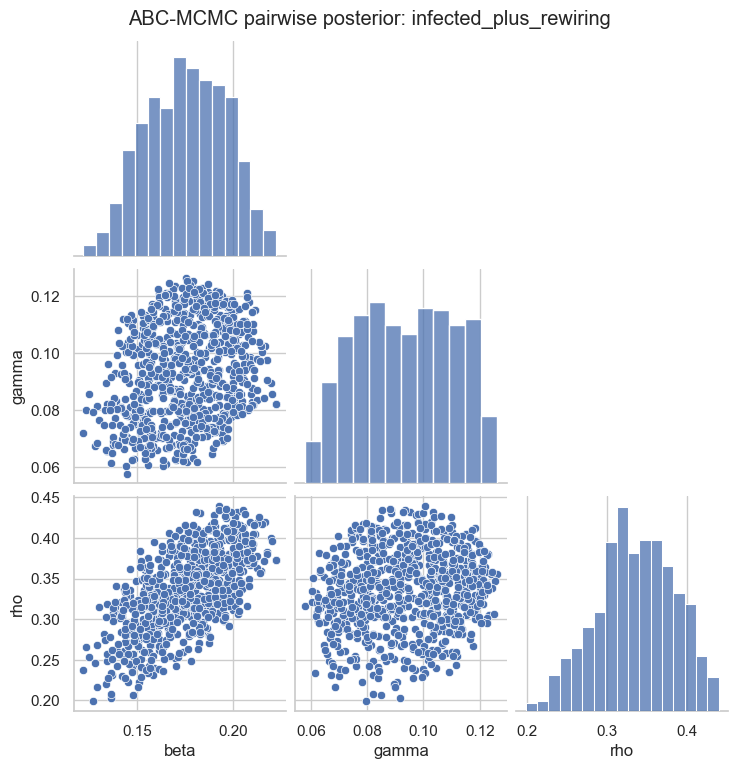

Rejection ABC means


,beta,gamma,rho
mean,0.168268,0.087876,0.318524


ABC-MCMC means


,beta,gamma,rho
mean,0.175594,0.093601,0.335537


In [33]:
plot_marginals(mcmc_posterior[["beta", "gamma", "rho"]], "ABC-MCMC posterior: infected_plus_rewiring")
plt.show()

plot_pairwise(mcmc_posterior[["beta", "gamma", "rho"]], "ABC-MCMC pairwise posterior: infected_plus_rewiring")
plt.show()

print("Rejection ABC means")
display(final_accepted[["beta", "gamma", "rho"]].mean().to_frame("mean").T)

print("ABC-MCMC means")
display(mcmc_posterior[["beta", "gamma", "rho"]].mean().to_frame("mean").T)


In [42]:
#0.8abcmcmc
import pandas as pd

abc_mcmc_new = pd.read_csv(
    "/Users/jiayibaobei/Desktop/Simulation-Based-Inference-for-an-Adaptive-Network-Epidemic-Model/abc_mcmc_results/results/abc_mcmc_posterior_infected_plus_rewiring.csv"
)

print("Rejection ABC means")
display(final_accepted[["beta", "gamma", "rho"]].mean().to_frame().T)

print("ABC-MCMC means")
display(abc_mcmc_new[["beta", "gamma", "rho"]].mean().to_frame().T)

display(abc_mcmc_new[["beta", "gamma", "rho"]].describe())



Rejection ABC means


,beta,gamma,rho
0,0.168268,0.087876,0.318524


ABC-MCMC means


,beta,gamma,rho
0,0.169026,0.088804,0.318548


,beta,gamma,rho
count,3200.000000,3200.000000,3200.000000
mean,0.169026,0.088804,0.318548
std,0.022370,0.015806,0.057168
min,0.116340,0.055770,0.184696
25%,0.151757,0.076405,0.276246
50%,0.169638,0.087767,0.318825
75%,0.186222,0.101014,0.363002
max,0.223522,0.125537,0.448976


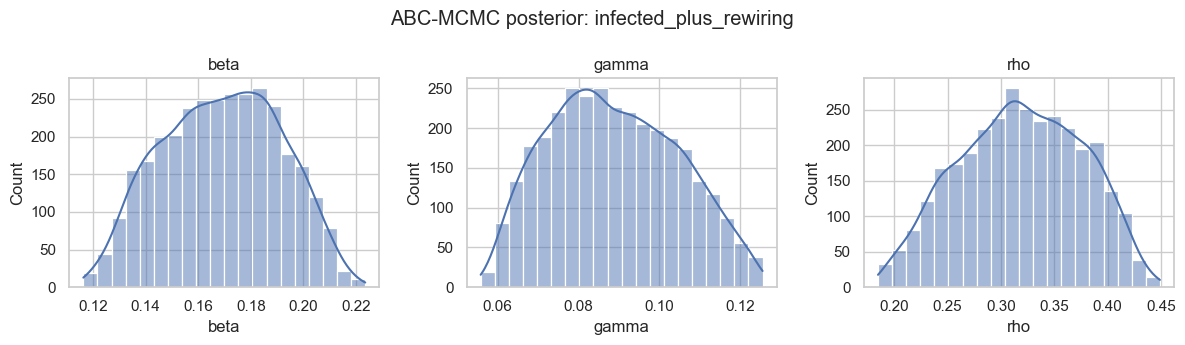

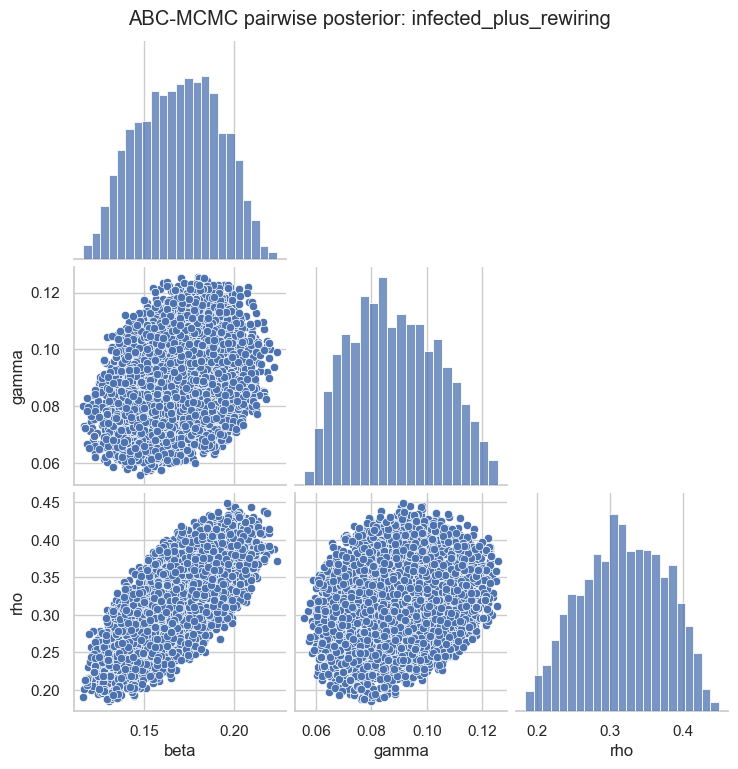

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

abc_mcmc_new = pd.read_csv(
    "/Users/jiayibaobei/Desktop/Simulation-Based-Inference-for-an-Adaptive-Network-Epidemic-Model/abc_mcmc_results/results/abc_mcmc_posterior_infected_plus_rewiring.csv"
)

plot_marginals(abc_mcmc_new, "ABC-MCMC posterior: infected_plus_rewiring")
plt.show()

plot_pairwise(abc_mcmc_new, "ABC-MCMC pairwise posterior: infected_plus_rewiring")
plt.show()


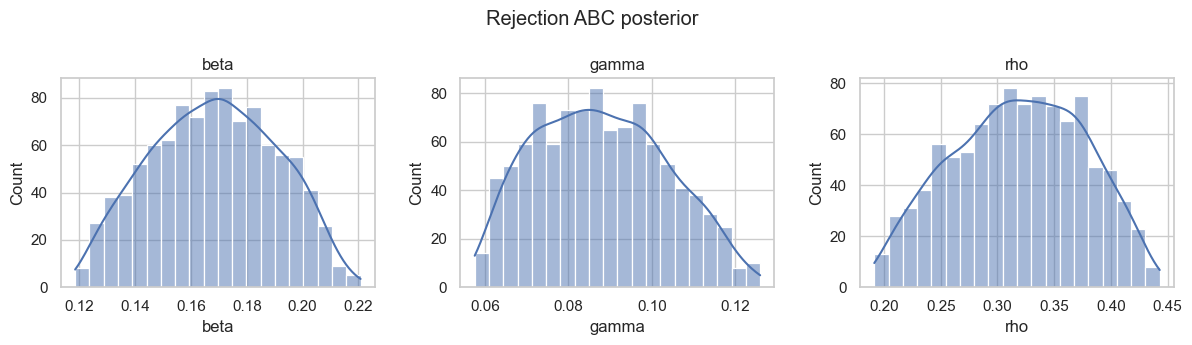

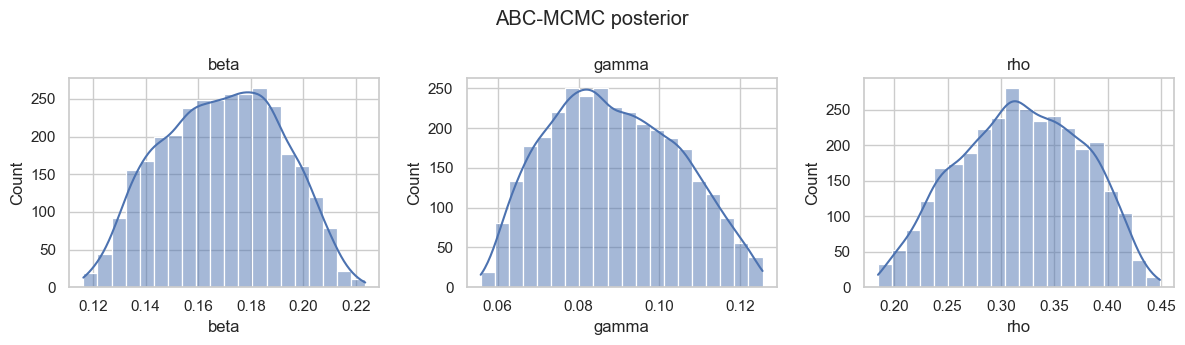

In [44]:
plot_marginals(final_accepted, "Rejection ABC posterior")
plt.show()

plot_marginals(abc_mcmc_new, "ABC-MCMC posterior")
plt.show()


## 13. PLS Summary Construction

This is an exploratory comparison only. We fit Partial Least Squares (PLS) on a simulated summary bank to compress the hand-crafted infected-plus-rewiring summaries into a lower-dimensional representation, then run rejection ABC on those PLS components.


In [36]:
from sklearn.cross_decomposition import PLSRegression

PLS_BASE_COLUMNS = SUMMARY_SETS["full"]


def simulate_summary_bank(n_samples=1000, n_reps=20, seed=3030):
    rng = np.random.default_rng(seed)
    theta = sample_prior(n_samples, rng)
    summaries = []

    for idx, row in enumerate(theta.itertuples(index=False), start=1):
        reps = simulate_replicates(
            row.beta,
            row.gamma,
            row.rho,
            n_reps=n_reps,
            seed=int(rng.integers(0, 2**31 - 1)),
        )
        summaries.append(summarize_replicates(reps))
        if idx % 200 == 0:
            print(f"Built {idx} / {n_samples} PLS training summaries", flush=True)

    return theta.reset_index(drop=True), pd.DataFrame(summaries).reset_index(drop=True)


def fit_pls_summary_model(summary_bank, theta_bank, base_columns, n_components=3):
    pls = PLSRegression(n_components=n_components, scale=True)
    pls.fit(summary_bank[base_columns], theta_bank[["beta", "gamma", "rho"]])
    return pls


def pls_transform_summary(pls_model, summary_series, base_columns):
    x = pd.DataFrame([summary_series[base_columns]], columns=base_columns)
    transformed = pls_model.transform(x)
    return pd.Series(transformed.ravel(), index=[f"pls_{i+1}" for i in range(transformed.shape[1])])


def rejection_abc_pls(
    observed_summary,
    pls_model,
    base_columns,
    n_samples=5000,
    n_reps=40,
    accept_frac=0.01,
    seed=4040,
):
    rng = np.random.default_rng(seed)
    theta = sample_prior(n_samples, rng)
    obs_pls = pls_transform_summary(pls_model, observed_summary, base_columns)
    rows = []

    for idx, row in enumerate(theta.itertuples(index=False), start=1):
        reps = simulate_replicates(
            row.beta,
            row.gamma,
            row.rho,
            n_reps=n_reps,
            seed=int(rng.integers(0, 2**31 - 1)),
        )
        sim_summary = summarize_replicates(reps)
        sim_pls = pls_transform_summary(pls_model, sim_summary, base_columns)
        dist = float(np.sqrt(np.sum((sim_pls - obs_pls) ** 2)))
        rows.append({
            "beta": row.beta,
            "gamma": row.gamma,
            "rho": row.rho,
            "distance": dist,
            **sim_pls.to_dict(),
        })
        if idx % 500 == 0:
            print(f"Processed {idx} / {n_samples} PLS-ABC samples", flush=True)

    results = pd.DataFrame(rows).sort_values("distance").reset_index(drop=True)
    n_accept = max(1, int(np.ceil(accept_frac * len(results))))
    accepted = results.head(n_accept).copy()
    return results, accepted


In [37]:
pls_theta_bank, pls_summary_bank = simulate_summary_bank(n_samples=1000, n_reps=20, seed=3030)
pls_model = fit_pls_summary_model(
    summary_bank=pls_summary_bank,
    theta_bank=pls_theta_bank,
    base_columns=PLS_BASE_COLUMNS,
    n_components=3,
)

pls_results, pls_accepted = rejection_abc_pls(
    observed_summary=observed_summary,
    pls_model=pls_model,
    base_columns=PLS_BASE_COLUMNS,
    n_samples=5000,
    n_reps=40,
    accept_frac=0.01,
    seed=4040,
)

print("PLS-ABC accepted samples:", len(pls_accepted))
pls_accepted[["beta", "gamma", "rho"]].describe()


Built 200 / 1000 PLS training summaries
Built 400 / 1000 PLS training summaries
Built 600 / 1000 PLS training summaries
Built 800 / 1000 PLS training summaries
Built 1000 / 1000 PLS training summaries
Processed 500 / 5000 PLS-ABC samples
Processed 1000 / 5000 PLS-ABC samples
Processed 1500 / 5000 PLS-ABC samples
Processed 2000 / 5000 PLS-ABC samples
Processed 2500 / 5000 PLS-ABC samples
Processed 3000 / 5000 PLS-ABC samples
Processed 3500 / 5000 PLS-ABC samples
Processed 4000 / 5000 PLS-ABC samples
Processed 4500 / 5000 PLS-ABC samples
Processed 5000 / 5000 PLS-ABC samples
PLS-ABC accepted samples: 50


,beta,gamma,rho
count,50.000000,50.000000,50.000000
mean,0.169191,0.089064,0.299101
std,0.023596,0.016726,0.051831
min,0.129322,0.062212,0.218357
25%,0.153763,0.076926,0.259285
50%,0.166829,0.087670,0.287714
75%,0.182932,0.102122,0.349877
max,0.228811,0.124663,0.399291


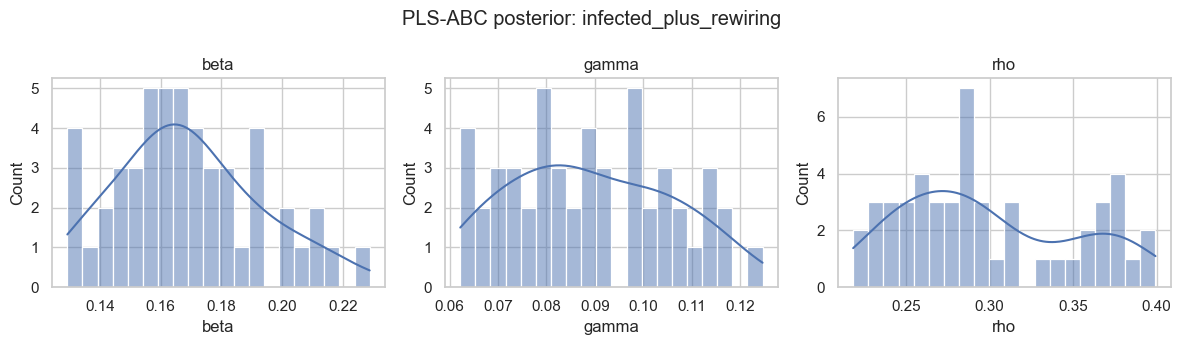

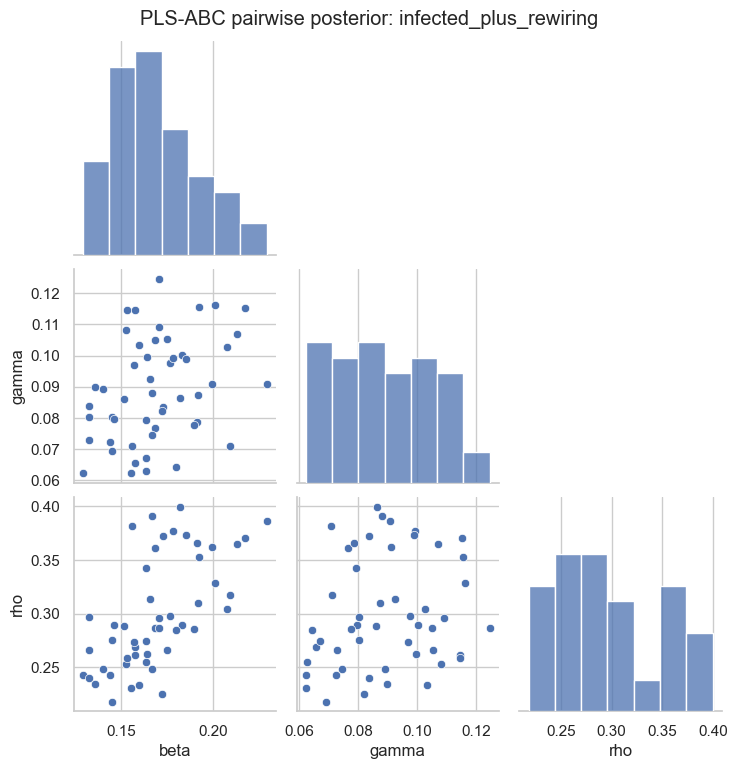

Rejection ABC means


,beta,gamma,rho
mean,0.168268,0.087876,0.318524


PLS-ABC means


,beta,gamma,rho
mean,0.169191,0.089064,0.299101


In [38]:
plot_marginals(pls_accepted[["beta", "gamma", "rho"]], "PLS-ABC posterior: infected_plus_rewiring")
plt.show()

plot_pairwise(pls_accepted[["beta", "gamma", "rho"]], "PLS-ABC pairwise posterior: infected_plus_rewiring")
plt.show()

print("Rejection ABC means")
display(final_accepted[["beta", "gamma", "rho"]].mean().to_frame("mean").T)

print("PLS-ABC means")
display(pls_accepted[["beta", "gamma", "rho"]].mean().to_frame("mean").T)


## 14. Rejection ABC (1,000,000 samples)

Load the downloaded million-sample rejection ABC result and plot it separately from the earlier 100,000-sample run.

In [45]:
rejection_abc_1m = pd.read_csv(
    "/Users/jiayibaobei/Desktop/Simulation-Based-Inference-for-an-Adaptive-Network-Epidemic-Model/rejection_abc_results/results/final_accepted_infected_plus_rewiring.csv"
)

print("Rejection ABC means (100,000 samples)")
display(final_accepted[["beta", "gamma", "rho"]].mean().to_frame("mean").T)

print("Rejection ABC means (1,000,000 samples)")
display(rejection_abc_1m[["beta", "gamma", "rho"]].mean().to_frame("mean").T)

display(rejection_abc_1m[["beta", "gamma", "rho"]].describe())


Rejection ABC means (100,000 samples)


,beta,gamma,rho
mean,0.168268,0.087876,0.318524


Rejection ABC means (1,000,000 samples)


,beta,gamma,rho
mean,0.168664,0.089009,0.31759


,beta,gamma,rho
count,10000.000000,10000.000000,10000.000000
mean,0.168664,0.089009,0.317590
std,0.022741,0.015953,0.056918
min,0.110871,0.055642,0.186247
25%,0.151180,0.076123,0.274085
50%,0.168682,0.088081,0.317397
75%,0.186383,0.101053,0.361977
max,0.228343,0.128543,0.449400


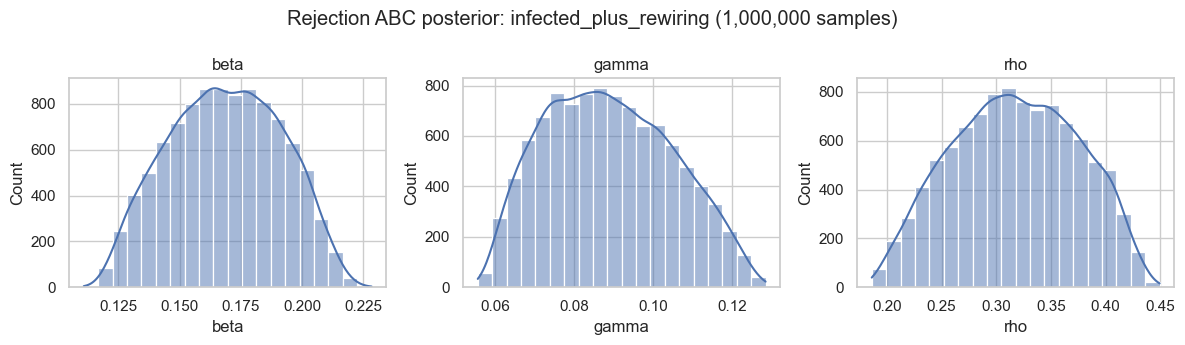

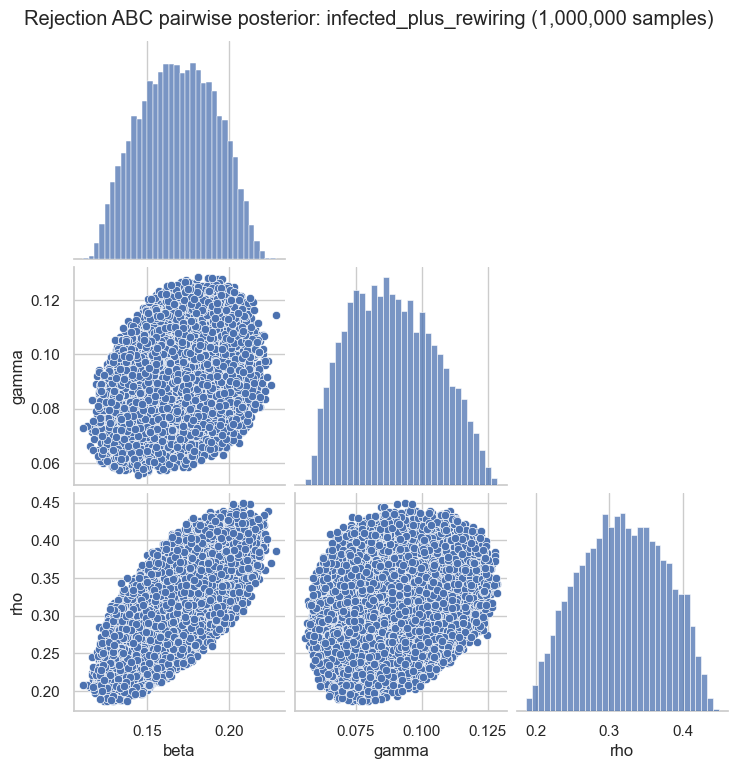

In [46]:
plot_marginals(rejection_abc_1m[["beta", "gamma", "rho"]], "Rejection ABC posterior: infected_plus_rewiring (1,000,000 samples)")
plt.show()

plot_pairwise(rejection_abc_1m[["beta", "gamma", "rho"]], "Rejection ABC pairwise posterior: infected_plus_rewiring (1,000,000 samples)")
plt.show()
